In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
%cd /content/drive/MyDrive/Colab Notebooks/LangChain

/content/drive/MyDrive/Colab Notebooks/LangChain


In [ ]:
!pip install -qU langchain langchain-openai langchain-community langchain-experimental
!pip install -qU langchain-chroma faiss-cpu langchain-teddynote
!pip install -qU langchain-tavily google-search-results pypdf
!pip install -qU mypy

In [ ]:
import os

In [ ]:
# OpenAI Key 환경변수설정
with open("./key/openai_key.txt", "r") as f:
    api_key = f.read().strip()

os.environ['OPENAI_API_KEY'] = api_key

In [ ]:
# 라이브러리 import
from uuid import uuid4

# 타입 설정
# Sequence : 메시지들의 순서 있는 시퀀스(리스트) 객체 (list 또는 tuple 형태로 메시지를 저장)
# Literal : 값 자체를 타입으로 제한할 수 있도록 해주는 기능
from typing import Annotated, TypedDict, Dict, List, Sequence, Literal
# pydantic : Python 데이터 검증과 설정 관리를 위한 라이브러리
from pydantic import Field, BaseModel, ValidationError

# 상태, 노드
# 노드 : 그래프에서의 작업 단위, 실제 작업을 수행하는 함수
from langgraph.graph.message import add_messages
from langgraph.graph import StateGraph, START, END
# 도구를 노드로 만드는 기능 (자동 맵핑, 상태업데이트, 다중 실행)
from langgraph.prebuilt import ToolNode
# 도구 노드의 결과에 따라 자동으로 라우팅 경로를 설정
from langgraph.prebuilt import tools_condition

# 메모리 저장소
from langgraph.checkpoint.memory import MemorySaver

# 실행 설정
from langchain_core.runnables import RunnableConfig

# 시각화
from IPython.display import Image, display, Markdown
from langchain_teddynote.messages import stream_graph

# 모델 설정
from langchain.chat_models import init_chat_model
from langchain_core.prompts import ChatPromptTemplate, PromptTemplate, MessagesPlaceholder
# BaseMessage : BaseMessage를 상속한 다양한 메시지 타입 (HumanMessage, AIMessage, SystemMessage)
from langchain_core.messages import HumanMessage, AIMessage, BaseMessage

# 웹 검색 도구
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_tavily import TavilySearch

# 도구 정의 데코레이터
from langchain.tools import tool

# RAG 라이브러리
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from langchain_openai import OpenAIEmbeddings

from langchain_core.runnables import RunnablePassthrough
from langchain_core.output_parsers import StrOutputParser

In [ ]:
%%writefile ./source/testDict.py
# 딕셔너리 생성
dict1 = {"name" : "홍길동", "age" : 24, "job" : "의적"}

# age를 문자열로 변경
dict1['age'] = "35"
#새로운 key 추가
dict1['region'] = "장성"

Overwriting ./source/testDict.py


In [ ]:
%%writefile ./source/testTypedDict.py
from typing import TypedDict

# 내가 지정한타입만 들어가는 나만의 dict 생성
class Person(TypedDict) :
    name : str
    age : int
    job : str

typed_dict1 : Person = {"name" : "홍길동", "age" : 24, "job" : "의적"}

# age를 문자열로 변경
typed_dict1['age'] = "35"
#새로운 key 추가
typed_dict1['region'] = "장성"

Overwriting ./source/testTypedDict.py


In [ ]:
# 실행 후 결과비교
!python3 -m mypy ./source/testDict.py

Success: no issues found in 1 source file


In [ ]:
!python -m mypy ./source/testTypedDict.py

source/testTypedDict.py:12: error: Value of "age" has incompatible type "str"; expected "int"  [typeddict-item]
source/testTypedDict.py:14: error: TypedDict "Person" has no key "region"  [typeddict-unknown-key]
Found 2 errors in 1 file (checked 1 source file)


### State(상태)

In [ ]:
# 기본 State 생성
class BasicState(TypedDict) :
    context : str
    question :str
    answer : str
    score : str
    relevance : str

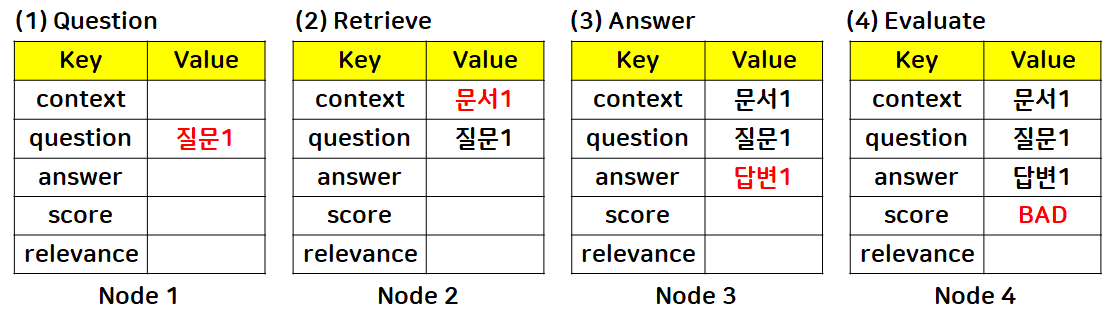

### Node

In [ ]:
# retrive_Node 정의
def retrive_Node(s : BasicState) -> BasicState :
    # 사용자 query에 맞는 chunck를 탐색했다고 가정하고 구성
    s['context'] = "광주는 현재 온도가 24도 입니다. 날씨가 화창하고 좋습니다."
    return s

In [ ]:
# llm_answer_Node 정의
def llm_answer_Node(s : BasicState) -> BasicState :
    # LLM이 답변을 생성했다고 가정하고 구성
    llm_answer = "오늘 광주는 24도 입니다. 날씨가 좋으니 산책해보시는건 어떨까요?"
    return BasicState(answer = llm_answer)

In [ ]:
# relevance_check_Node 정의
def relevance_check_Node(s : BasicState) -> BasicState :
    # retrelever로 검색된 데이터와 LLM이 생성한 답변의 일치도를 검사한다고 가정
    s['relevance'] = 'grounded' # 검색 문서기반으로 답변이 생성되었다고 표현하는 값 업데이트
    return s

In [ ]:
# 노드 등록하기
graph_builder = StateGraph(BasicState)  # 그래프의 베이스 생성

graph_builder.add_node("retrive_Node", retrive_Node)    # 노드이름 , 수행가능한 노드 함수
graph_builder.add_node("llm_answer_Node", llm_answer_Node)
graph_builder.add_node("relevance_check_Node", relevance_check_Node)

### Edge

In [ ]:
graph_builder.add_edge("retrive_Node", "llm_answer_Node")   # 시작노드, 끝 노드
graph_builder.add_edge("llm_answer_Node", "relevance_check_Node")

### Conditional Edge (조건부 엣지)

In [ ]:
# router 함수
def is_relevant(s : BasicState) -> Literal['grounded', 'notGrounded', 'notSure'] :
    return s['relevance']

In [ ]:
graph_builder.add_conditional_edges(
    source = "relevance_check_Node",        # 조건부 엣지를 붙일 노드이름
    path = is_relevant,                     # 조건분기를 판별하는 함수
    path_map = {                            # 분기될 노드 지정
        'grounded' : END,                   # 문서기반 답변인 경우 끝낸다
        'notGrounded' : 'llm_answer_Node',  # 문서기반 답변이 아니면 LLM으로 보내 재생성
        'notSure' : 'retrive_Node'          # 모호한 경우 문서검색부터 다시
    }
)

### 그래프 생성 및 시각화

In [ ]:
# 시작점 지정
graph_builder.set_entry_point('retrive_Node')

In [ ]:
# 그래프 컴파일
graph = graph_builder.compile()

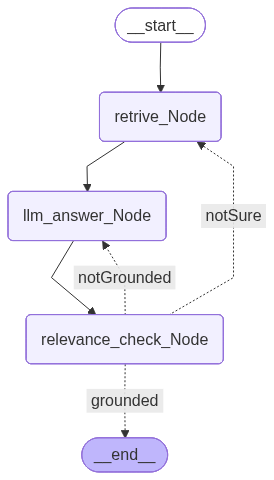

In [ ]:
# 그래프 시각화
display(Image(graph.get_graph().draw_mermaid_png()))

# LangGraph 챗봇 구성하기

## 1\. 상태정의

In [ ]:
class ChatbotState(TypedDict) :
    # 리스트에 메세지들을 자동으로 추가
    messages : Annotated[list, "사용자의 메세지를 담는 리스트"]

## 2\. 노드정의

In [ ]:
# LLM 생성
llm = init_chat_model(model="openai:gpt-4o-mini", max_tokens=500)

In [ ]:
def chatbot(s : ChatbotState) :
    # 메세지 호출 및 반환
    response = llm.invoke(s['messages'])
    return ChatbotState(messages=[response])

## 3\. 그래프 생성 및 노드 추가

In [ ]:
chatbot_graph_builder = StateGraph(ChatbotState)

chatbot_graph_builder.add_node("chatbot", chatbot)

## 4\. 엣지 추가

In [ ]:
chatbot_graph_builder.set_entry_point("chatbot")
chatbot_graph_builder.add_edge("chatbot", END)

## 5\. 그래프 컴파일

In [ ]:
chatbot_graph = chatbot_graph_builder.compile()

## 6\. 그래프 시각화

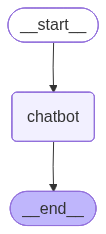

In [ ]:
# 그래프 시각화
display(Image(chatbot_graph.get_graph().draw_mermaid_png()))

## 7\. 그래프 실행

In [ ]:
question = "광주의 유명한 맛집 TOP3 추천해줘"
response = chatbot_graph.invoke({"messages" : [('user', question)]})

In [ ]:
response

{'messages': [AIMessage(content='광주는 맛집이 많은 도시로, 다양한 음식 문화를 즐길 수 있습니다. 여기 광주에서 유명한 맛집 TOP3를 추천해드릴게요:\n\n1. **전주비빔밥** - 광주에서 유명한 전주비빔밥 전문점으로, 신선한 재료와 고소한 맛이 특징입니다. 사용할 때마다 신선한 재료를 제공하여 건강한 한 끼를 즐길 수 있습니다.\n\n2. **무등가 메밀국수** - 이곳은 시원하고 담백한 메밀국수를 제공하는 맛집입니다. 특히 여름철에 인기가 많으며, 직접 만든 메밀면과 신선한 야채가 어우러져 고소한 맛을 느낄 수 있습니다.\n\n3. **광주식당** - 전통적인 광주 음식을 경험할 수 있는 곳으로, 특히 전라도식 한정식과 찌개가 유명합니다. 다양한 반찬과 함께 푸짐한 한상을 제공하여 식사 만족도가 높습니다.\n\n이 외에도 광주에는 많은 맛집이 있으니, 다양한 음식을 즐겨보시길 바랍니다!', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 249, 'prompt_tokens': 18, 'total_tokens': 267, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_def81a1071', 'id': 'chatcmpl-DySQhjLnh8Gnx9w99VnglymLXtrbB', 'service_tier': 'default', 'fin

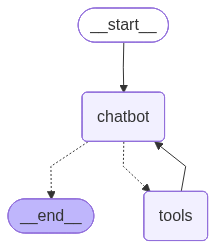

In [ ]:
# 웹 검색을 위한 key 등록
with open("./key/tavily_key.txt", "r") as f:
    api_key = f.read().strip()

os.environ['TAVILY_API_KEY'] = api_key

In [ ]:
# 상태(state) 정의
class webChatbotState(TypedDict) :
    messages: Annotated[list, add_messages]

# 검색 도구 생성
tool_tavily = TavilySearch(maxresults=3)

# LLM 모델 생성
llm = init_chat_model(model="openai:gpt-4o-mini", max_tokens=500, temperature=0)

# 도구를 LLM 모델에 바인딩 -> 사용여부를 LLM이 스스로 결정
llm_with_tools = llm.bind_tools([tool_tavily])

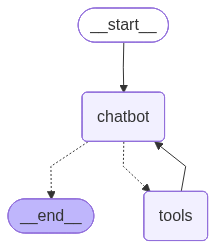

In [ ]:
# chatbot 노드 정의
def chatbot(s : webChatbotState) -> webChatbotState :
    response = llm_with_tools.invoke(s['messages'])
    return {"messages": [response]} #LLM 응답을 state에 실어서 반환

# 그래프 생성 및 노드 추가
graph_builder2 = StateGraph(webChatbotState) # 그래프 베이스 생성
graph_builder2.add_node("chatbot", chatbot)

#LLM 모델 판단에 따라 실행되는 Tool Node 생성
tool_node = ToolNode([tool_tavily])
# Tool Node 등록
graph_builder2.add_node("tools", tool_node)

#edge 연결
graph_builder2.add_edge(START, "chatbot")
graph_builder2.add_conditional_edges("chatbot", tools_condition)
graph_builder2.add_edge("tools", "chatbot")
#컴파일 및 시각화
graph2 = graph_builder2.compile()
display(Image(graph2.get_graph().draw_mermaid_png()))

In [ ]:
#그래프 실행
question = "오늘 광주 날씨 알려줘"
res = graph2.invoke({"messages" : [('user',question)]})
print(res['messages'][-1].content)
display(res)


오늘 광주의 날씨는 다음과 같습니다:

- **현재 기온**: 23°C
- **날씨 상태**: 대체로 흐림
- **체감 온도**: 28°C
- **예상 강수량**: 약간의 비가 예상되며, 최고 기온은 26°C입니다.
- **바람**: 가벼운 바람 (6 - 11 km/h)
- **습도**: 98%
- **시야**: 14 km
- **기압**: 1007 mb

자세한 정보는 [MSN 날씨](https://www.msn.com/ko-kr/weather/forecast/in-%EA%B4%91%EC%A3%BC%EA%B4%91%EC%97%AD%EC%8B%9C,%20%EA%B4%91%EC%A3%BC)에서 확인하실 수 있습니다.


{'messages': [HumanMessage(content='오늘 광주 날씨 알려줘', additional_kwargs={}, response_metadata={}, id='9f793cd9-08da-4bf7-9241-49f06aa7e07b'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 28, 'prompt_tokens': 1194, 'total_tokens': 1222, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_3be5422b9d', 'id': 'chatcmpl-DySQlpTNG1rQ2OSAnTuiurWkOfnVb', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019f350a-fa5c-79a2-9492-20f9ac94be9b-0', tool_calls=[{'name': 'tavily_search', 'args': {'query': '광주 날씨', 'time_range': 'day', 'topic': 'general'}, 'id': 'call_kIxRJJAkiMoX7U9VYJuHmtRx', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metada

##Agent에 메모리(memory) 추가하기




In [ ]:
# chatbot 노드 정의
def chatbot(s : webChatbotState) -> webChatbotState :
    response = llm_with_tools.invoke(s['messages'])
    return {"messages": [response]} #LLM 응답을 state에 실어서 반환

# 그래프 생성 및 노드 추가
graph_builder = StateGraph(webChatbotState) # 그래프 베이스 생성
graph_builder.add_node("chatbot", chatbot)

#LLM 모델 판단에 따라 실행되는 Tool Node 생성
tool_node = ToolNode([tool_tavily])
# Tool Node 등록
graph_builder.add_node("tools", tool_node)

#edge 연결
graph_builder.add_edge(START, "chatbot")
graph_builder.add_conditional_edges("chatbot", tools_condition)
graph_builder.add_edge("tools", "chatbot")
#컴파일 및 시각화


### MeMorySaver 생성


In [ ]:
memory = MemorySaver() # 인메모리 세이버

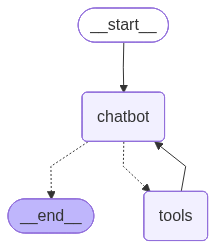

In [ ]:
# 컴파일 및 시각화
graph = graph_builder.compile(checkpointer = memory)
display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
# config 설정
config = RunnableConfig(
    configurable={"thread_id" : "001"}
)

In [ ]:
#그래프 실행
question = "내가 좋아하는 요리 추천해줘"
res = graph.invoke({"messages" : [('user',question)]}, config = config)
print(res['messages'][-1].content)
display(res)


좋아하는 요리에 대해 좀 더 구체적으로 말씀해 주시면 더 맞춤형 추천을 드릴 수 있을 것 같아요. 예를 들어, 어떤 종류의 요리를 좋아하시나요? (한식, 중식, 양식 등) 또는 특정 재료나 맛(매운, 달콤한 등)을 선호하시나요?


{'messages': [HumanMessage(content='내가 좋아하는 요리 추천해줘', additional_kwargs={}, response_metadata={}, id='dbe8a967-31d8-4661-92c3-88ea0c8702b2'),
  AIMessage(content='좋아하는 요리에 대해 좀 더 구체적으로 말씀해 주시면 더 맞춤형 추천을 드릴 수 있을 것 같아요. 예를 들어, 어떤 종류의 요리를 좋아하시나요? (한식, 중식, 양식 등) 또는 특정 재료나 맛(매운, 달콤한 등)을 선호하시나요?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 75, 'prompt_tokens': 1196, 'total_tokens': 1271, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_3be5422b9d', 'id': 'chatcmpl-DySRC2afwgpj9aHUog2Co9YnOE1EP', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019f350b-61c3-79f1-b9a6-d77c24aa6c65-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 1196, 'out

##Stream 모드 사용하기

In [ ]:
# 웹 검색을 위한 key 등록
with open("./key/serp_api_key.txt", "r") as f:
    api_key = f.read().strip()

os.environ['SERPAPI_API_KEY'] = api_key


In [ ]:
from langchain_community.utilities import SerpAPIWrapper

In [ ]:
# 상태(state) 정의
class webChatbotState(TypedDict) :
    messages: Annotated[list, add_messages]
    # 테스트를 위한 더미변수
    dummy_data : Annotated[str, "dummy"]

# tool 정의
@tool
def search_keyword(query : str) -> List[Dict[str,str]] :
    '''키워드로 구글 뉴스 검색'''
    search = SerpAPIWrapper()
    return search.results(query)

# LLM 모델 생성
llm = init_chat_model(model="openai:gpt-4o-mini", max_tokens=500, temperature=0)

# 도구를 LLM 모델에 바인딩 -> 사용여부를 LLM이 스스로 결정
llm_with_tools = llm.bind_tools([search_keyword])


In [ ]:
# chatbot 노드 정의
def chatbot(s : webChatbotState) -> webChatbotState :
    response = llm_with_tools.invoke(s['messages'])
    return {"messages": [response]} #LLM 응답을 state에 실어서 반환

# 그래프 생성 및 노드 추가
graph_builder = StateGraph(webChatbotState) # 그래프 베이스 생성
graph_builder.add_node("chatbot", chatbot)

#LLM 모델 판단에 따라 실행되는 Tool Node 생성
tool_node = ToolNode([search_keyword])
# Tool Node 등록
graph_builder.add_node("tools", tool_node)

#edge 연결
graph_builder.add_edge(START, "chatbot")
graph_builder.add_conditional_edges("chatbot", tools_condition)
graph_builder.add_edge("tools", "chatbot")



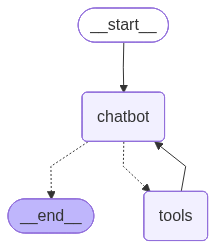

In [ ]:
memory = MemorySaver() # 인메모리 세이버
# 컴파일 및 시각화
graph = graph_builder.compile(checkpointer = memory)
display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
# config 설정
config = RunnableConfig(
    configurable={"thread_id" : "002"}, #메모리 구분 id
    recursion_limit = 20 # 그래프 실행 중에 노드를 수행하는 횟수 최대치

)

In [ ]:
# 질문
question = "2026년 AI 관련 알려줘."

# 입력으로 넣을 초기 상태값 정의
input = webChatbotState(messages=[('user', question)],
                        dummy_data = "테스트 문자열")

# 각 노드들의 실행결과를 반환
# stream_mode
# - updates(기본값) : 노드에서 업데이트한 속성 값 출력
# - values : 노드에서 출력되는 state를 그대로 출력
for res in graph.stream(input=input, config=config, stream_mode="values") :
    print(res)
    # for value in res.values():
        #value['messages'][-1].pretty_print()

{'messages': [HumanMessage(content='2026년 AI 관련 알려줘.', additional_kwargs={}, response_metadata={}, id='af305643-11c8-405f-b217-a8c73658e2c2')], 'dummy_data': '테스트 문자열'}
{'messages': [HumanMessage(content='2026년 AI 관련 알려줘.', additional_kwargs={}, response_metadata={}, id='af305643-11c8-405f-b217-a8c73658e2c2'), AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 16, 'prompt_tokens': 54, 'total_tokens': 70, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_def81a1071', 'id': 'chatcmpl-DySRLsTnbD4rjdhIcy6SLrYyKqUEw', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019f350b-846d-7ab2-9ed2-c626d82e6c1c-0', tool_calls=[{'name': 'search_keyword'

 # Naive RAG

- 상태정의

In [ ]:
class RAGState(TypedDict) :
    question : Annotated[str, "User Question"] #사용자 질문
    context : Annotated[str, "Context"] # 관련 문서 검색 결과
    answer : Annotated[str, "Answer"] # LLM 응답
    messages : Annotated[list, add_messages] # 메세지(list로 누적)

- 문서로드/Chunking/임베딩/벡터DB저장/검색기 설정

In [ ]:
# 문서 로드
loader = PyPDFLoader("./data/SPRi AI Brief_11월호산업동향.pdf")
documents = loader.load()

documents

[Document(metadata={'producer': 'Hancom PDF 1.3.0.547', 'creator': 'Hwp 2018 10.0.0.13947', 'creationdate': '2024-11-05T15:04:26+09:00', 'author': 'dj', 'moddate': '2024-11-05T15:04:26+09:00', 'pdfversion': '1.4', 'source': './data/SPRi AI Brief_11월호산업동향.pdf', 'total_pages': 25, 'page': 0, 'page_label': '1'}, page_content='2024년 11월호'),
 Document(metadata={'producer': 'Hancom PDF 1.3.0.547', 'creator': 'Hwp 2018 10.0.0.13947', 'creationdate': '2024-11-05T15:04:26+09:00', 'author': 'dj', 'moddate': '2024-11-05T15:04:26+09:00', 'pdfversion': '1.4', 'source': './data/SPRi AI Brief_11월호산업동향.pdf', 'total_pages': 25, 'page': 1, 'page_label': '2'}, page_content='2024년 11월호\nⅠ. 인공지능 산업 동향 브리프 1. 정책/법제    ▹ 미국 민권위원회, 연방정부의 얼굴인식 기술 사용에 따른 민권 영향 분석························1   ▹ 미국 백악관 예산관리국, 정부의 책임 있는 AI 조달을 위한 지침 발표·····························2   ▹ 유로폴, 법 집행에서 AI의 이점과 과제를 다룬 보고서 발간··············································3   ▹ OECD, 공공 부문의 AI 도입을 위한 G7 툴킷 발표·································

In [ ]:
# Chunking
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=500, # 청크의 크기
    chunk_overlap=50, # 청크끼리 겹쳐지는 글자 수
)
texts = text_splitter.split_documents(documents)
for t in texts :
    print(len(t.page_content))

10
10
497
491
496
290
393
17
277
496
495
334
256
497
497
375
267
496
499
345
228
498
496
368
270
498
497
360
273
497
492
282
259
498
498
116
134
258
499
498
475
260
495
498
67
116
229
499
498
54
132
266
498
499
248
244
498
494
495
95
266
495
499
379
223
498
496
120
277
273
499
495
190
277
497
498
402
252
494
497
242
284
497
492
273
247
496
496
292
268
498
496
492
74
487
241
227


In [ ]:
# 임베딩/벡터DB저장
vec_db = FAISS.from_documents(texts, OpenAIEmbeddings())

In [ ]:
# 검색키 설정
retriever = vec_db.as_retriever(search_kwargs={"k":2})

- 노드 정의

In [ ]:
#LLM 초기화
llm = init_chat_model(model="openai:gpt-4o-mini", max_tokens=500, temperature=0)

#문서 검색 노드
def retrieve_node(s : RAGState) -> RAGState :
    # 사용자 질문기반 검색
    docs = retriever.invoke(s['question'])
    # 검색된 Document 객체들을 하나의 문자열로 병합
    context_str = "\n\n".join([d.page_content for d in docs])

    return {"context" : context_str}

# 답변 생성 노드
def llm_answer(s : RAGState) -> RAGState :
    # 프롬프트 설정
    system_prompt = """
        당신은 유능한 어시스턴트입니다. 아래 검색된 내용을 바탕으로 답변하세요.
        답변 시 출처(source) 정보도 포함해 주세요.

        [context]
    """
    #템플릿 생성
    template = ChatPromptTemplate.from_messages([
        ('system', system_prompt),
        MessagesPlaceholder(variable_name="chat_history"),
        ('human', "{input}"),
    ])

    # 체인 연결하기
    chain = template | llm | StrOutputParser()

    # 체인 호출
    response = chain.invoke(
        {
            "context" : s['context'],
            "chat_history" : s.get("messages", []),
            "input" : s['question']
        }
    )
    return RAGState(
        answer = response,
        messages = [('user', s['question']), ('ai', response)]
    )

- 그래프 생성 및 실행

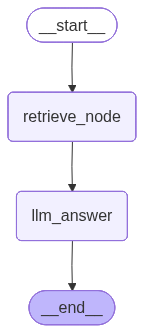

In [ ]:
# 1. 그래프 생성
graph_builder = StateGraph(RAGState)

# 2. 노드 추가
graph_builder.add_node("retrieve_node", retrieve_node)
graph_builder.add_node("llm_answer", chatbot)

# 3. 엣지 추가
graph_builder.add_edge(START, "retrieve_node")
graph_builder.add_edge("retrieve_node", "llm_answer")
graph_builder.add_edge("llm_answer", END)

# 4. 메모리(체크포인트) 생성
memory = MemorySaver()

# 5. 그래프 컴파일 및 시각화
graph = graph_builder.compile(checkpointer=memory)

display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
# 실행을 위한 가상 스레드 설정
config = RunnableConfig(
    configurable={"thread_id": "004"}
)

# 입력 데이터 설정
query = "광주에서 가장 유명한 맛집이 어디야?"

# 그래프 스트리밍 실행
output = graph.invoke(input = RAGState(question=query), config=config)


BadRequestError: Error code: 400 - {'error': {'message': "Invalid 'messages': empty array. Expected an array with minimum length 1, but got an empty array instead.", 'type': 'invalid_request_error', 'param': 'messages', 'code': 'empty_array'}}

 # 관련성 체커 (Relevance Check) 모듈 추가

- 관련성 결과를 저장하는 상태 속성 추가

In [ ]:
class RAGState(TypedDict) :
    question : Annotated[str, "User Question"] #사용자 질문
    context : Annotated[str, "Context"] # 관련 문서 검색 결과
    answer : Annotated[str, "Answer"] # LLM 응답
    messages : Annotated[list, add_messages] # 메세지(list로 누적)
    relevance : Annotated[str, "Relevance"] # 관련성 체크결과 (yes or no)

- 관련성 체크 노드 추가

In [ ]:
#출력 구조 정의
class RelevanceScore(BaseModel) :
    score : str = Field(description="사용자 질문과 문서가 관련 있으면 'yes', 없으면 'no'")

# 관련성 체크 노드 구현
def relevance_check(s : RAGState) -> RAGState :
    #구조화 된 출력으로 설정한 LLM
    structured_llm = llm.with_structured_output(RelevanceScore)

    #평가 프롬프트
    system_prompt = '''
        당신은 검색된 문서와 사용자 질문간의 관련성을 평가하는 역할입니다.
        검색된 문서(context)가 사용자 질문(question)에 대답하는 데 도움이 되는 정보를 포함하고 있는지 확인해주세요.

        -조금이라도 관련이 있다면 'yes'
        -전혀 관련이 없는 내용이라면 'no'
        -오직 'yes' 또는 'no'로 대답해주세요.
    '''
    template = ChatPromptTemplate.from_messages([
        ('system', system_prompt),
        ('human', "Context : {context} \n\n Question : {question}"),
    ])
    # 체인 구성 및 실행
    checker_chain = template | structured_llm
    response = checker_chain.invoke(
        {
            "context" : s['context'],
            "question" : s['question']
        }
    )
    # 확인용 출력
    print(f"======[RELEVANCE CHECK] : {response.score}")
    # 상태업데이트 리턴
    return RAGState(relevance=response.score)

In [ ]:
# 1. 그래프 생성
graph_builder = StateGraph(RAGState)

# 2. 노드 추가
graph_builder.add_node("retrieve_node", retrieve_node)
graph_builder.add_node("relevance_check", relevance_check) # 관련성 검사 노드 추가
graph_builder.add_node("llm_answer", llm_answer)

# 3. 엣지 추가
graph_builder.add_edge(START, "retrieve_node")
graph_builder.add_edge("retrieve_node", "relevance_check")
# 조건부 엣지 추가
def is_relevant(s:RAGState) -> RAGState :
    return s['relevance']
graph_builder.add_conditional_edges(
    "relevance_check", # 조건 분기 시작노드
    is_relevant, # 라우터 함수 추가
    { # 분기에 따른 연결 노드 설정
        "yes" : "llm_answer",
        "no" : "retrieve_node"
    }
)
graph_builder.add_edge("llm_answer", END)

# 4. 메모리(체크포인트) 생성
memory = MemorySaver()

# 5. 그래프 컴파일 및 시각화
graph = graph_builder.compile(checkpointer=memory)

display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
config = RunnableConfig(
    configurable = {"thread_id" : "005"},
    recursion_limit = 20, #최대 재귀횟수 설정
)
# query = "생셩형 AI가 인간 그로자를 대체할 가능성에 대해서 어떻게 생각하니?"
query = "2026년 AI 트랜드 알려줘"
input = RAGState(question=query)
#예외 처리
try :
    output = graph.invoke(input =input , config=config)
except GraphRecursionError as e :
    print("재귀 횟수 초과")
    print(e)


 # 웹 검색 모듈 추가

- Web Search 노드 정의

In [ ]:
# 도구 생성
tavily_tool = TavilySearch(max_resuls=3)

In [ ]:
class RAGState(TypedDict) :
    question : Annotated[str, "User Question"] #사용자 질문
    context : Annotated[str, "context"] # 관련 문서 검색 결과
    answer : Annotated[str, "Answer"] # LLM 응답
    messages : Annotated[list, add_messages] # 메세지(list로 누적)
    relevance : Annotated[str, "Relevance"] # 관련성 체크결과 (yes or no)
    web_search : Annotated[str, "Web Search"] # 웹 검색 결과

In [ ]:
#출력 구조 정의
class RelevanceScore(BaseModel) :
    score : str = Field(description="사용자 질문과 문서가 관련 있으면 'yes', 없으면 'no'")

#문서 검색 노드
def retrieve_node(s : RAGState) -> RAGState :
    # 사용자 질문기반 검색
    docs = retriever.invoke(s['question'])
    # 검색된 Document 객체들을 하나의 문자열로 병합
    context_str = "\n\n".join([d.page_content for d in docs])

    return {"context" : context_str}

# 관련성 체크 노드 구현
def relevance_check(s : RAGState) -> RAGState :
    #구조화 된 출력으로 설정한 LLM
    structured_llm = llm.with_structured_output(RelevanceScore)

    #평가 프롬프트
    system_prompt = '''
        당신은 검색된 문서와 사용자 질문간의 관련성을 평가하는 역할입니다.
        검색된 문서(context)가 사용자 질문(question)에 대답하는 데 도움이 되는 정보를 포함하고 있는지 확인해주세요.

        -조금이라도 관련이 있다면 'yes'
        -전혀 관련이 없는 내용이라면 'no'
        -오직 'yes' 또는 'no'로 대답해주세요.
    '''
    template = ChatPromptTemplate.from_messages([
        ('system', system_prompt),
        ('human', "Context : {context} \n\n Question : {question}"),
    ])
    # 체인 구성 및 실행
    checker_chain = template | structured_llm
    response = checker_chain.invoke(
        {
            "context" : s['context'],
            "question" : s['question']
        }
    )
    # 확인용 출력
    print(f"======[RELEVANCE CHECK] : {response.score}")
    # 상태업데이트 리턴
    return RAGState(relevance=response.score)

# web_search 노드 생성
def web_search(s: RAGState) -> RAGState:

    # 검색결과 반환
    search_result = tavily_tool.invoke(s["question"])

    #검색결과를 하나로 병합
    context = "\n\n".join([
        doc['content'] for doc in search_result['results']
    ])

    return RAGState(context=context)

In [1]:
tavily_tool.invoke("삼성전자 주가")

NameError: name 'tavily_tool' is not defined

- 그래프 구성하기

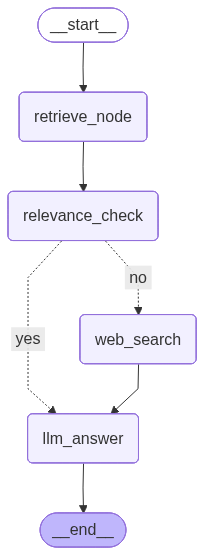

In [ ]:
# 1. 그래프 생성
graph_builder = StateGraph(RAGState)

# 2. 노드 추가
graph_builder.add_node("retrieve_node", retrieve_node)
graph_builder.add_node("relevance_check", relevance_check) # 관련성 검사 노드 추가
graph_builder.add_node("web_search", web_search) # 웹 검색 노드 추가
graph_builder.add_node("llm_answer", llm_answer)

# 3. 엣지 추가
graph_builder.add_edge(START, "retrieve_node")
graph_builder.add_edge("retrieve_node", "relevance_check")


# 조건부 엣지 추가
def is_relevant(s:RAGState) -> RAGState :
    return s['relevance']
graph_builder.add_conditional_edges(
    "relevance_check", # 조건 분기 시작노드
    is_relevant, # 라우터 함수 추가
    { # 분기에 따른 연결 노드 설정
        "yes" : "llm_answer",
        "no" : "web_search"
    }
)
graph_builder.add_edge("web_search", "llm_answer")
graph_builder.add_edge("llm_answer", END)


# 4. 메모리(체크포인트) 생성
memory = MemorySaver()

# 5. 그래프 컴파일 및 시각화
graph = graph_builder.compile(checkpointer=memory)

display(Image(graph.get_graph().draw_mermaid_png()))

-실행


In [ ]:
#config
config = RunnableConfig(
    configurable = {"thread_id" : "006"},
    recursion_limit = 10, #최대 재귀횟수 설정
)

In [2]:
query = "양자 컴퓨터에 대해서 알려줘"
input = RAGState(question=query)

#그래프 실행
for result in graph.stream(input=input, config=config) :
    print(result)

NameError: name 'RAGState' is not defined

 # 쿼리 재작성 모듈 추가

In [ ]:
rewrite_prompt = ChatPromptTemplate.from_template("""
 벡터 스토어 검색의 효율성을 높이기 위해 주어진 질문을 재공식화한다.

- 초기 질문을 분석하여 특이성, 명확성, 관련성 등 개선이 필요한 영역을 식별한다.
- 검색을 최적화할 수 있는 컨텍스트 및 잠재적 키워드를 고려한다.
- 원래 질문의 의도를 유지하면서 구조와 어휘를 강화한다.

# 처리 프로세스

1. **원래 질문 이해**: 핵심 의도와 키워드를 식별한다.
2. **명확성 향상**: 언어를 단순화하고 질문이 직접적이고 요점이 명확하도록 한다.
3. **검색 최적화**: 벡터스토어 인덱싱과 더 잘 일치하도록 키워드를 추가하거나 재배열한다.
4. **검토**: 개선된 질문이 원래 의도를 정확하게 반영하고 모호함이 없는지 확인한다.

# 출력 형식

- 개선된 단일 질문을 제공한다.
- 소개나 설명 텍스트를 포함하지 마세요. 단지 재구성된 질문일 뿐이다.

# 예시

**입력**:
"화석 연료에 비해 재생 가능 에너지원의 이점은 ?"

**출력**:
"재생 가능 에너지원은 이점 측면에서 화석 연료와 어떤 장점/단점/특징을 가지고 있습니까?"

**입력**:
"기후 변화와 북극곰 개체수 ?"

**출력**:
"어떤 기후 변화가 북극곰 개체수에 어떤 영향을 미치나요?"

# 메모

- 개선된 질문이 간결하고 상황에 맞는지 확인하세요.
- 원래 질문의 근본적인 의도나 의미를 변경하지 마십시오.

[주의점] 다시 작성된 질문은 원래 질문과 동일한 언어로 작성되어야 합니다.

# 다시 작성해야 할 원래 질문은 다음과 같다.:
{question}
""")

#체인구성
question_rewriter = rewrite_prompt | llm | StrOutputParser()

In [ ]:
#체인 호출
question_rewriter.invoke({"question" : "AI 타분야 적용 사례"})

'"AI는 어떤 타분야에서 어떻게 적용되고 있습니까?"'

In [ ]:
# Query rewrite 노드 정의
def query_rewrite(s: RAGState) -> RAGState:

    rewritten_question = question_rewriter.invoke(s['question'])
    print(f"""
    === [Query rewrite]:
        - 기존 : {s['question']}
        - 변경 : {rewritten_question}
    """)
    return RAGState(question=rewritten_question)

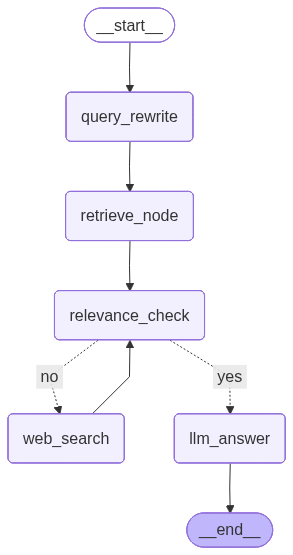

In [ ]:
# 1. 그래프 생성
graph_builder = StateGraph(RAGState)

# 2. 노드 추가
graph_builder.add_node("query_rewrite", query_rewrite)
graph_builder.add_node("retrieve_node", retrieve_node)
graph_builder.add_node("relevance_check", relevance_check)
graph_builder.add_node("web_search", web_search)
graph_builder.add_node("llm_answer", llm_answer)


# 3. 엣지 추가
graph_builder.add_edge(START, "query_rewrite")
graph_builder.add_edge("query_rewrite", "retrieve_node")
graph_builder.add_edge("retrieve_node", "relevance_check")
# 조건부 엣지 추가
def is_relevant(s:RAGState) -> RAGState :
    return s['relevance']
graph_builder.add_conditional_edges(
    "relevance_check", # 조건 분기 시작노드
    is_relevant, # 라우터 함수 추가
    { # 분기에 따른 연결 노드 설정
        "yes" : "llm_answer",
        "no" : "web_search"
    }
)
graph_builder.add_edge("web_search", "relevance_check")
graph_builder.add_edge("llm_answer", END)


# 4. 메모리(체크포인트) 생성
memory = MemorySaver()

# 5. 그래프 컴파일 및 시각화
graph = graph_builder.compile(checkpointer=memory)

display(Image(graph.get_graph().draw_mermaid_png()))

In [3]:
query = "삼성전자 주가"
input = RAGState(question=query)

#그래프 실행
for result in graph.stream(input=input, config=config) :
    print(result)

NameError: name 'RAGState' is not defined

- web search 검색 결과에 대한 검증성이 no인 경우는 deep_search 같은 속성을 state에 추가하고 기존 web api 이외에 다른 api가 호출되도록 웹 서치 노드를 수정하면 된다.